# Hospital Mortality Prediction (HOSPITAL_EXPIRE_FLAG)
## Computational Machine Learning - Final Project 2025

**Author:** Corneel Moons  
**Date:** December 2025  
**Task:** Binary Classification - Predicting ICU Patient Mortality

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Setup & Imports](#2-setup)
3. [Data Loading & Exploration](#3-data-loading)
4. [Preprocessing Pipeline](#4-preprocessing)
5. [Model Selection & Cross-Validation](#5-model-selection)
6. [Hyperparameter Tuning with GridSearchCV](#6-gridsearch)
7. [Final Model & Evaluation](#7-final-model)
8. [Predictions & Submission](#8-predictions)
9. [Conclusion](#9-conclusion)

---

<a id='1-introduction'></a>
## 1. Introduction

### Objective
Predict the probability of in-hospital mortality (`HOSPITAL_EXPIRE_FLAG`) for ICU patients.

### Dataset
- **Source:** MIMIC-III (Medical Information Mart for Intensive Care III)
- **Training set:** 20,885 ICU stays
- **Test set:** 5,221 ICU stays
- **Target:** Binary (0 = survived, 1 = died)
- **Class imbalance:** ~11% mortality rate (roughly 8:1 ratio)

### Approach
1. Feature engineering with clinical domain knowledge
2. Handle class imbalance with stratified cross-validation
3. Compare baseline and advanced models
4. Tune hyperparameters with GridSearchCV
5. Evaluate with ROC-AUC metric

<a id='2-setup'></a>
## 2. Setup & Imports

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================

# Data manipulation
import numpy as np
import pandas as pd
from pathlib import Path

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Model evaluation
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful")

All imports successful


<a id='3-data-loading'></a>
## 3. Data Loading & Exploration

In [3]:
# =============================================================================
# LOAD DATA
# =============================================================================

data_path = Path("../data/")

# Load datasets
train_raw = pd.read_csv(data_path / "mimic_train_HEF.csv", low_memory=False)
test_raw = pd.read_csv(data_path / "mimic_test_HEF.csv", low_memory=False)
diagnoses_raw = pd.read_csv(data_path / "extra_data" / "MIMIC_diagnoses.csv")

# Working copies
train = train_raw.copy()
test = test_raw.copy()
diagnoses = diagnoses_raw.copy()
diagnoses.columns = diagnoses.columns.str.upper()

print(f"Training set: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Test set: {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"Diagnoses: {diagnoses.shape[0]:,} records")

Training set: 20,885 rows x 44 columns
Test set: 5,221 rows x 39 columns
Diagnoses: 651,047 records


EXPLORATORY DATA ANALYSIS


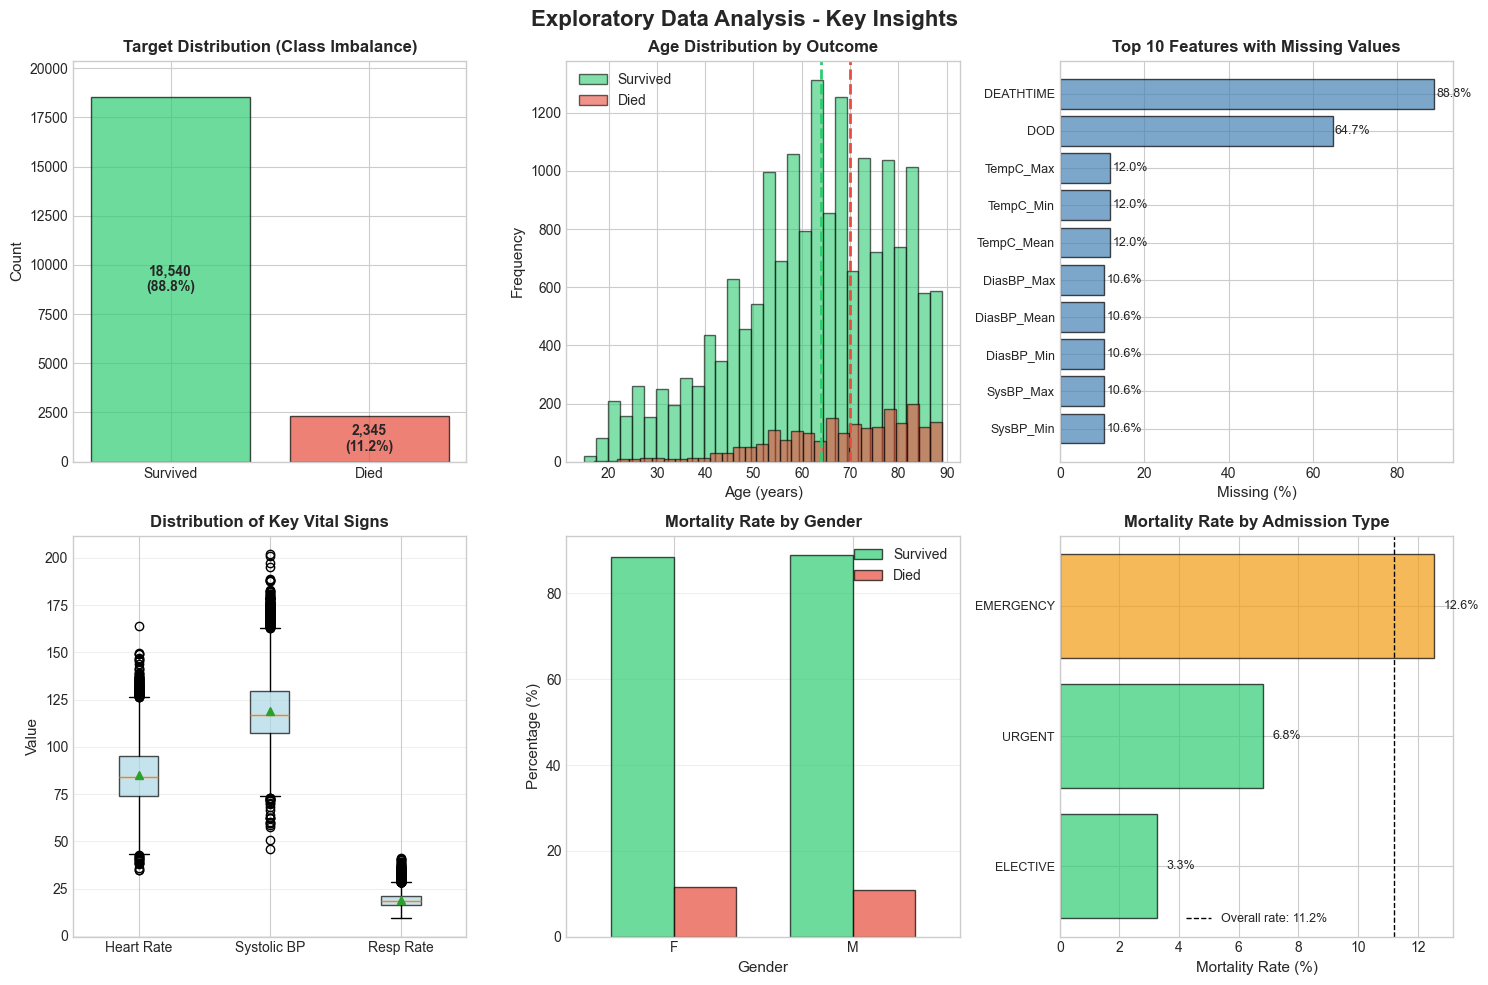


KEY STATISTICS

1. CLASS IMBALANCE
   Survived: 18,540 (88.8%)
   Died:     2,345 (11.2%)
   --> Stratified CV is essential!

2. MISSING DATA
   Features with missing: 27
   Most missing: DEATHTIME (88.8%)
   --> Imputation strategy: median (numeric), mode (categorical)

3. FEATURE TYPES
   Numeric: 30
   Categorical: 14
   --> Requires encoding strategy

4. GENDER DISTRIBUTION
   M: 11,759 (56.3%) - Mortality: 11.0%
   F: 9,126 (43.7%) - Mortality: 11.6%

5. AGE INSIGHTS
   Overall median age: 64 years
   Died median age:    70 years
   Survived median age: 64 years
   --> Older patients have higher mortality risk



In [4]:
# =============================================================================
# 3.1 EXPLORATORY DATA ANALYSIS
# =============================================================================

print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis - Key Insights', fontsize=16, fontweight='bold')

# -------------------------------------------------------------------------
# 1. TARGET DISTRIBUTION
# -------------------------------------------------------------------------
ax = axes[0, 0]
target_counts = train['HOSPITAL_EXPIRE_FLAG'].value_counts()
colors = ['#2ecc71', '#e74c3c']
ax.bar(['Survived', 'Died'], target_counts.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Target Distribution (Class Imbalance)', fontweight='bold')
ax.text(0, target_counts[0]/2, f'{target_counts[0]:,}\n(88.8%)', 
        ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(1, target_counts[1]/2, f'{target_counts[1]:,}\n(11.2%)', 
        ha='center', va='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, target_counts[0] * 1.1)

# -------------------------------------------------------------------------
# 2. AGE DISTRIBUTION BY OUTCOME
# -------------------------------------------------------------------------
ax = axes[0, 1]
# Calculate age for visualization (handle MIMIC-III quirks)
train_vis = train.copy()
train_vis['DOB'] = pd.to_datetime(train_vis['DOB'], errors='coerce')
train_vis['ADMITTIME_temp'] = pd.to_datetime(train_vis['ADMITTIME'], errors='coerce')
train_vis['age_vis'] = train_vis['ADMITTIME_temp'].dt.year - train_vis['DOB'].dt.year
train_vis.loc[(train_vis['age_vis'] < 0) | (train_vis['age_vis'] > 120), 'age_vis'] = np.nan

survived = train_vis[train_vis['HOSPITAL_EXPIRE_FLAG'] == 0]['age_vis'].dropna()
died = train_vis[train_vis['HOSPITAL_EXPIRE_FLAG'] == 1]['age_vis'].dropna()

ax.hist(survived, bins=30, alpha=0.6, label='Survived', color='#2ecc71', edgecolor='black')
ax.hist(died, bins=30, alpha=0.6, label='Died', color='#e74c3c', edgecolor='black')
ax.set_xlabel('Age (years)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Age Distribution by Outcome', fontweight='bold')
ax.legend()
ax.axvline(died.median(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Died median: {died.median():.0f}')
ax.axvline(survived.median(), color='#2ecc71', linestyle='--', linewidth=2, label=f'Survived median: {survived.median():.0f}')

# -------------------------------------------------------------------------
# 3. MISSING VALUES
# -------------------------------------------------------------------------
ax = axes[0, 2]
missing_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0].head(10)

if len(missing_pct) > 0:
    ax.barh(range(len(missing_pct)), missing_pct.values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(missing_pct)))
    ax.set_yticklabels(missing_pct.index, fontsize=9)
    ax.set_xlabel('Missing (%)', fontsize=11)
    ax.set_title('Top 10 Features with Missing Values', fontweight='bold')
    ax.invert_yaxis()
    for i, v in enumerate(missing_pct.values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
else:
    ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=12)
    ax.axis('off')

# -------------------------------------------------------------------------
# 4. VITAL SIGNS DISTRIBUTIONS (KEY FEATURES)
# -------------------------------------------------------------------------
ax = axes[1, 0]
vital_signs = ['HeartRate_Mean', 'SysBP_Mean', 'RespRate_Mean']
vital_names = ['Heart Rate', 'Systolic BP', 'Resp Rate']

data_to_plot = [train[col].dropna() for col in vital_signs if col in train.columns]
if data_to_plot:
    bp = ax.boxplot(data_to_plot, labels=vital_names[:len(data_to_plot)], 
                    patch_artist=True, showmeans=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title('Distribution of Key Vital Signs', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Vital signs not available', ha='center', va='center', fontsize=12)
    ax.axis('off')

# -------------------------------------------------------------------------
# 5. GENDER DISTRIBUTION BY OUTCOME
# -------------------------------------------------------------------------
ax = axes[1, 1]
if 'GENDER' in train.columns:
    gender_outcome = pd.crosstab(train['GENDER'], train['HOSPITAL_EXPIRE_FLAG'], normalize='index') * 100
    gender_outcome.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], 
                        alpha=0.7, edgecolor='black', width=0.7)
    ax.set_xlabel('Gender', fontsize=11)
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_title('Mortality Rate by Gender', fontweight='bold')
    ax.legend(['Survived', 'Died'], loc='upper right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.grid(axis='y', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Gender data not available', ha='center', va='center', fontsize=12)
    ax.axis('off')

# -------------------------------------------------------------------------
# 6. ADMISSION TYPE BY OUTCOME
# -------------------------------------------------------------------------
ax = axes[1, 2]
if 'ADMISSION_TYPE' in train.columns:
    # Calculate mortality rate by admission type
    admission_mortality = train.groupby('ADMISSION_TYPE')['HOSPITAL_EXPIRE_FLAG'].agg(['mean', 'count'])
    admission_mortality = admission_mortality[admission_mortality['count'] > 50]  # Filter rare types
    admission_mortality = admission_mortality.sort_values('mean', ascending=True)
    
    colors_adm = ['#e74c3c' if x > 0.15 else '#f39c12' if x > 0.10 else '#2ecc71' 
                  for x in admission_mortality['mean']]
    
    ax.barh(range(len(admission_mortality)), admission_mortality['mean'] * 100, 
            color=colors_adm, alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(admission_mortality)))
    ax.set_yticklabels(admission_mortality.index, fontsize=9)
    ax.set_xlabel('Mortality Rate (%)', fontsize=11)
    ax.set_title('Mortality Rate by Admission Type', fontweight='bold')
    ax.axvline(11.2, color='black', linestyle='--', linewidth=1, label='Overall rate: 11.2%')
    ax.legend(fontsize=9)
    
    for i, v in enumerate(admission_mortality['mean'] * 100):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
else:
    ax.text(0.5, 0.5, 'Admission type not available', ha='center', va='center', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# KEY STATISTICS SUMMARY
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("KEY STATISTICS")
print("="*60)

print("\n1. CLASS IMBALANCE")
print(f"   Survived: {(train['HOSPITAL_EXPIRE_FLAG']==0).sum():,} ({(train['HOSPITAL_EXPIRE_FLAG']==0).mean():.1%})")
print(f"   Died:     {(train['HOSPITAL_EXPIRE_FLAG']==1).sum():,} ({(train['HOSPITAL_EXPIRE_FLAG']==1).mean():.1%})")
print(f"   --> Stratified CV is essential!")

print("\n2. MISSING DATA")
missing_summary = train.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_summary) > 0:
    print(f"   Features with missing: {len(missing_summary)}")
    print(f"   Most missing: {missing_summary.index[0]} ({missing_summary.iloc[0]/len(train)*100:.1f}%)")
    print(f"   --> Imputation strategy: median (numeric), mode (categorical)")
else:
    print("   No missing values detected")

print("\n3. FEATURE TYPES")
print(f"   Numeric: {len(train.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"   Categorical: {len(train.select_dtypes(include=['object']).columns)}")
print(f"   --> Requires encoding strategy")

if 'GENDER' in train.columns:
    print("\n4. GENDER DISTRIBUTION")
    gender_dist = train['GENDER'].value_counts()
    for gender, count in gender_dist.items():
        mortality_rate = train[train['GENDER']==gender]['HOSPITAL_EXPIRE_FLAG'].mean()
        print(f"   {gender}: {count:,} ({count/len(train):.1%}) - Mortality: {mortality_rate:.1%}")

print("\n5. AGE INSIGHTS")
if 'age_vis' in train_vis.columns:
    print(f"   Overall median age: {train_vis['age_vis'].median():.0f} years")
    print(f"   Died median age:    {died.median():.0f} years")
    print(f"   Survived median age: {survived.median():.0f} years")
    print(f"   --> Older patients have higher mortality risk")

print("\n" + "="*60)

<a id='4-preprocessing'></a>
## 4. Preprocessing Pipeline

### Steps:
1. Create hospital history features
2. Create diagnosis-based features
3. Remove leakage columns
4. Calculate age from DOB
5. Impute missing values
6. Encode categorical variables
7. Create medical severity features
8. Scale continuous features

In [ ]:
# =============================================================================
# 4.1 HOSPITAL HISTORY FEATURES
# =============================================================================
# Rationale: Patients with multiple ICU visits may have different risk profiles

# Sort by patient and time for correct ordering
train['ADMITTIME'] = pd.to_datetime(train['ADMITTIME'], errors='coerce')
test['ADMITTIME'] = pd.to_datetime(test['ADMITTIME'], errors='coerce')
train = train.sort_values(['subject_id', 'ADMITTIME'])
test = test.sort_values(['subject_id', 'ADMITTIME'])

# Count previous ICU stays for each patient
train['n_previous_icu_stays'] = train.groupby('subject_id').cumcount()
test['n_previous_icu_stays'] = test.groupby('subject_id').cumcount()

# Is this the first ICU visit?
train['is_first_icu_visit'] = (train['n_previous_icu_stays'] == 0).astype(int)
test['is_first_icu_visit'] = (test['n_previous_icu_stays'] == 0).astype(int)

# Save test IDs in correct order (CRITICAL for submission)    --> Because we sorted test in step 2, the rows are no longer in the original order of the CSV file
test_ids = test['icustay_id'].copy()

print("Hospital history features created:")
print(f"  - n_previous_icu_stays: range [{train['n_previous_icu_stays'].min()}, {train['n_previous_icu_stays'].max()}]")
print(f"  - is_first_icu_visit: {train['is_first_icu_visit'].mean():.1%} are first-time patients")

Hospital history features created:
  - n_previous_icu_stays: range [0, 24]
  - is_first_icu_visit: 78.1% are first-time patients


In [ ]:
# =============================================================================
# 4.2 DIAGNOSIS FEATURES
# =============================================================================
# Rationale: Diagnosis codes contain important clinical information

# Number of diagnoses per admission (indicator of complexity) --> patient with 1 diagnosis is likely less critical than a patient with 15 diagnoses
n_diag = diagnoses.groupby('HADM_ID').size()
train['n_diagnoses'] = train['hadm_id'].map(n_diag).fillna(0).astype(int)
test['n_diagnoses'] = test['hadm_id'].map(n_diag).fillna(0).astype(int)

# Get primary diagnosis (SEQ_NUM = 1) --> While a patient might have 10 codes, the first one usually drives the risk
primary_diag = diagnoses[diagnoses['SEQ_NUM'] == 1].set_index('HADM_ID')['ICD9_CODE']
train['primary_diagnosis'] = train['hadm_id'].map(primary_diag)
test['primary_diagnosis'] = test['hadm_id'].map(primary_diag)

# Extract ICD9 category (first 3 characters)  --> Reduces thousands of granular codes into fewer broader categories
def get_icd9_category(code):
    if pd.isna(code):
        return 'UNKNOWN'
    return str(code).replace('.', '')[:3]

train['icd9_category'] = train['primary_diagnosis'].apply(get_icd9_category)
test['icd9_category'] = test['primary_diagnosis'].apply(get_icd9_category)

# High-risk condition flags based on ICD9 codes --> Expert Feature Engineering: Instead of hoping the ML model figures out that 995.91 is dangerous, you explicitly tell it: "This patient has Sepsis"
all_diag_per_hadm = diagnoses.groupby('HADM_ID')['ICD9_CODE'].apply(
    lambda x: set(str(c).replace('.', '') for c in x)
)

def has_condition(hadm_id, prefixes):
    """Check if patient has any diagnosis starting with given prefixes"""
    if hadm_id not in all_diag_per_hadm.index:
        return 0
    codes = all_diag_per_hadm[hadm_id]
    return int(any(c.startswith(p) for c in codes for p in prefixes))

# Define high-risk conditions
conditions = {
    'has_sepsis': ['99591', '99592', '78552'],
    'has_heart_failure': ['428'],
    'has_respiratory_failure': ['518'],
    'has_aki': ['584'],  # Acute kidney injury
}

for name, prefixes in conditions.items():
    train[name] = train['hadm_id'].apply(lambda x: has_condition(x, prefixes))
    test[name] = test['hadm_id'].apply(lambda x: has_condition(x, prefixes))

print("Diagnosis features created:")
print(f"  - n_diagnoses: mean={train['n_diagnoses'].mean():.1f}")
for name in conditions:
    print(f"  - {name}: {train[name].mean():.1%}")

Diagnosis features created:
  - n_diagnoses: mean=14.8
  - has_sepsis: 13.4%
  - has_heart_failure: 26.2%
  - has_respiratory_failure: 29.3%
  - has_aki: 28.0%


In [7]:
# =============================================================================
# 4.3 REMOVE LEAKAGE COLUMNS
# =============================================================================
# These columns reveal the outcome or are not available at prediction time

leakage_cols = [
    'DEATHTIME',       # Directly reveals death
    'DOD',             # Date of death
    'DISCHTIME',       # Only known after discharge
    'LOS',             # Length of stay - outcome related
    'Diff',            # Time difference - leakage
    'ADMITTIME',       # Already used for sorting
    'primary_diagnosis',  # Will use encoded version
]

id_cols = ['icustay_id', 'subject_id', 'hadm_id']

cols_to_drop = [c for c in leakage_cols + id_cols if c in train.columns]
train = train.drop(columns=cols_to_drop, errors='ignore')
test = test.drop(columns=[c for c in cols_to_drop if c in test.columns], errors='ignore')

# Separate target
y = train['HOSPITAL_EXPIRE_FLAG'].copy()
X = train.drop('HOSPITAL_EXPIRE_FLAG', axis=1)
X_test = test.copy()

print(f"After removing leakage: X shape = {X.shape}")

After removing leakage: X shape = (20885, 42)


In [10]:
# =============================================================================
# 4.4 AGE CALCULATION
# =============================================================================
# MIMIC-III shifts birth dates for patients >89 years for privacy
# This causes overflow when calculating age directly

if 'DOB' in X.columns:
    # Load original ADMITTIME for age calculation
    train_orig = pd.read_csv(data_path / 'mimic_train_HEF.csv')
    test_orig = pd.read_csv(data_path / 'mimic_test_HEF.csv')
    
    # Convert to datetime
    dob_train = pd.to_datetime(X['DOB'], errors='coerce')
    dob_test = pd.to_datetime(X_test['DOB'], errors='coerce')
    admit_train = pd.to_datetime(train_orig['ADMITTIME'], errors='coerce')
    admit_test = pd.to_datetime(test_orig['ADMITTIME'], errors='coerce')
    
    # Calculate age using year difference (avoids overflow)
    X['age'] = admit_train.dt.year - dob_train.dt.year
    X_test['age'] = admit_test.dt.year - dob_test.dt.year
    
    # Handle invalid ages (MIMIC privacy shifts cause negative or very high ages)
    mask_train = (X['age'] < 0) | (X['age'] > 120)
    mask_test = (X_test['age'] < 0) | (X_test['age'] > 120)
    
    X.loc[mask_train, 'age'] = 90
    X_test.loc[mask_test, 'age'] = 90
    
    # Drop DOB
    X = X.drop('DOB', axis=1)
    X_test = X_test.drop('DOB', axis=1)
    
    print(f"Age calculated: mean={X['age'].mean():.1f}, median={X['age'].median():.1f}")

In [ ]:
# =============================================================================
# 4.5 MISSING VALUE IMPUTATION
# =============================================================================
# Strategy: median for numeric, mode for categorical

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

# Impute numeric with median
if numeric_cols:
    num_imputer = SimpleImputer(strategy='median')
    X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])
    X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])   # --> If you calculated the median of the Test set, you would be "peeking" at the test data distribution. That is data leakage.

# Impute categorical with mode
if categorical_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])
    X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

print(f"Missing values after imputation: {X.isnull().sum().sum()}")

Numeric features: 32
Categorical features: 10
Missing values after imputation: 0


In [14]:
# =============================================================================
# 4.6 CATEGORICAL ENCODING 
# =============================================================================

# 1. HANDLE DIAGNOSIS CATEGORIES (Safe Strategy: Top-20 + Other)
# Rationale: Avoids leakage from Target Encoding and high cardinality of One-Hot
if 'icd9_category' in X.columns:
    # Identify top 20 most frequent categories in TRAIN
    top_20_diag = X['icd9_category'].value_counts().nlargest(20).index
    
    # Apply to Train and Test (Test must use Train's top 20 list!)
    X['icd9_grouped'] = X['icd9_category'].where(X['icd9_category'].isin(top_20_diag), 'OTHER')
    X_test['icd9_grouped'] = X_test['icd9_category'].where(X_test['icd9_category'].isin(top_20_diag), 'OTHER')
    
    # Drop the original high-cardinality column
    X = X.drop('icd9_category', axis=1)
    X_test = X_test.drop('icd9_category', axis=1)
    
    # Add the new 'icd9_grouped' to categorical list for One-Hot Encoding
    if 'icd9_category' in categorical_cols:
        categorical_cols.remove('icd9_category')
    categorical_cols.append('icd9_grouped')
    
    print(f"Grouped icd9_category into {len(top_20_diag)+1} values (Top 20 + OTHER)")

# 2. DROP RAW TEXT
if 'DIAGNOSIS' in X.columns:
    X = X.drop('DIAGNOSIS', axis=1)
    X_test = X_test.drop('DIAGNOSIS', axis=1)
    if 'DIAGNOSIS' in categorical_cols:
        categorical_cols.remove('DIAGNOSIS')
    print("Dropped: DIAGNOSIS (free text)")

# 3. ONE-HOT ENCODE EVERYTHING (Safe & Standard)
# Now includes the 'icd9_grouped' we just created
remaining_cat = [c for c in categorical_cols if c in X.columns]

if remaining_cat:
    # Create dummies
    X = pd.get_dummies(X, columns=remaining_cat, drop_first=True, dtype=int)
    X_test = pd.get_dummies(X_test, columns=remaining_cat, drop_first=True, dtype=int)
    
    # CRITICAL: Align columns (ensure Test has exact same columns as Train)
    missing_cols = set(X.columns) - set(X_test.columns)
    for col in missing_cols:
        X_test[col] = 0
    
    # Ensure order is identical
    X_test = X_test[X.columns]
    
    print(f"One-hot encoded: {len(remaining_cat)} features (including icd9_grouped)")

print(f"\nFinal shape: X={X.shape}, X_test={X_test.shape}")


Final shape: X=(20885, 1958), X_test=(5221, 1958)


In [15]:
# =============================================================================
# 4.7 MEDICAL SEVERITY FEATURES
# =============================================================================
# Rationale: Clinical indicators that are known predictors of ICU mortality

# Shock Index = Heart Rate / Systolic BP
# Normal < 0.7, Elevated > 0.9 indicates hemodynamic instability
if 'HeartRate_Mean' in X.columns and 'SysBP_Mean' in X.columns:
    X['ShockIndex'] = (X['HeartRate_Mean'] / (X['SysBP_Mean'] + 1)).clip(0, 3)
    X_test['ShockIndex'] = (X_test['HeartRate_Mean'] / (X_test['SysBP_Mean'] + 1)).clip(0, 3)
    print("Created: ShockIndex (HR/SBP)")

# Hypoxemia indicator (SpO2 < 90%)
if 'SpO2_Min' in X.columns:
    X['Hypoxemia'] = (X['SpO2_Min'] < 90).astype(int)
    X_test['Hypoxemia'] = (X_test['SpO2_Min'] < 90).astype(int)
    print(f"Created: Hypoxemia (SpO2 < 90%): {X['Hypoxemia'].mean():.1%}")

# Fever indicator (Temp > 38°C)
if 'TempC_Max' in X.columns:
    X['Fever'] = (X['TempC_Max'] > 38).astype(int)
    X_test['Fever'] = (X_test['TempC_Max'] > 38).astype(int)
    print(f"Created: Fever (Temp > 38°C): {X['Fever'].mean():.1%}")

# Elderly indicator (age > 65)
if 'age' in X.columns:
    X['Elderly'] = (X['age'] > 65).astype(int)
    X_test['Elderly'] = (X_test['age'] > 65).astype(int)
    print(f"Created: Elderly (age > 65): {X['Elderly'].mean():.1%}")

Created: ShockIndex (HR/SBP)
Created: Hypoxemia (SpO2 < 90%): 19.7%
Created: Fever (Temp > 38°C): 17.2%
Created: Elderly (age > 65): 45.1%


In [16]:
# =============================================================================
# 4.8 FEATURE SCALING
# =============================================================================
# Only scale continuous features, not binary indicators

# Identify binary columns (should not be scaled)
binary_cols = [c for c in X.columns if X[c].nunique() <= 2]

# Identify continuous columns to scale
continuous_cols = [c for c in X.select_dtypes(include=['float64', 'int64']).columns 
                   if c not in binary_cols]

print(f"Binary features (not scaled): {len(binary_cols)}")
print(f"Continuous features (scaled): {len(continuous_cols)}")

# Scale continuous features
if continuous_cols:
    scaler = StandardScaler()
    X[continuous_cols] = scaler.fit_transform(X[continuous_cols])
    X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])
    print("StandardScaler applied to continuous features")

Binary features (not scaled): 1933
Continuous features (scaled): 29
StandardScaler applied to continuous features


In [17]:
# =============================================================================
# 4.9 FINAL VALIDATION
# =============================================================================

print("="*60)
print("PREPROCESSING COMPLETE")
print("="*60)

# Checks
assert X.shape[0] == len(y), "X and y length mismatch"
assert X.shape[1] == X_test.shape[1], "Train/test feature mismatch"
assert X.isnull().sum().sum() == 0, "Missing values in X"
assert X_test.isnull().sum().sum() == 0, "Missing values in X_test"
assert len(test_ids) == len(X_test), "Test IDs mismatch"

print(f"\nDataset ready:")
print(f"  X_train: {X.shape}")
print(f"  y_train: {y.shape} (mortality rate: {y.mean():.1%})")
print(f"  X_test:  {X_test.shape}")
print(f"  test_ids: {len(test_ids)}")

PREPROCESSING COMPLETE

Dataset ready:
  X_train: (20885, 1962)
  y_train: (20885,) (mortality rate: 11.2%)
  X_test:  (5221, 1962)
  test_ids: 5221


<a id='5-model-selection'></a>
## 5. Model Selection & Cross-Validation

We compare multiple models using **Stratified K-Fold Cross-Validation**:
- Stratified: preserves the class imbalance ratio in each fold
- 5 folds: standard choice, good bias-variance trade-off
- Metric: ROC-AUC (appropriate for imbalanced classification)

In [ ]:
# =============================================================================
# 5.1 CROSS-VALIDATION SETUP
# =============================================================================

# Stratified K-Fold: preserves class ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  #--> If we don't shuffle now, your folds would be "Patients A-E", "Patients F-J", etc. Shuffling mixes them up so you don't overfit to specific patient groups.

print("Cross-Validation Setup:")
print(f"  Method: Stratified 5-Fold")
print(f"  Metric: ROC-AUC")
print(f"  Shuffle: Yes (random_state={RANDOM_STATE})")

Cross-Validation Setup:
  Method: Stratified 5-Fold
  Metric: ROC-AUC
  Shuffle: Yes (random_state=42)


In [19]:
# =============================================================================
# 5.2 BASELINE: LOGISTIC REGRESSION
# =============================================================================

print("="*60)
print("MODEL 1: LOGISTIC REGRESSION (Baseline)")
print("="*60)

# Logistic Regression with balanced class weights
# class_weight='balanced' adjusts weights inversely proportional to class frequencies
lr_model = LogisticRegression(
    class_weight='balanced',  # Handle class imbalance
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Cross-validation
lr_scores = cross_val_score(lr_model, X, y, cv=cv, scoring='roc_auc')

print(f"\nCV Scores per fold: {[f'{s:.4f}' for s in lr_scores]}")
print(f"Mean ROC-AUC: {lr_scores.mean():.4f}")
print(f"Std: {lr_scores.std():.4f}")

MODEL 1: LOGISTIC REGRESSION (Baseline)

CV Scores per fold: ['0.8767', '0.8827', '0.8781', '0.8958', '0.8766']
Mean ROC-AUC: 0.8820
Std: 0.0073


In [20]:
# =============================================================================
# 5.3 RANDOM FOREST
# =============================================================================

print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')

print(f"\nCV Scores per fold: {[f'{s:.4f}' for s in rf_scores]}")
print(f"Mean ROC-AUC: {rf_scores.mean():.4f}")
print(f"Std: {rf_scores.std():.4f}")


MODEL 2: RANDOM FOREST

CV Scores per fold: ['0.8786', '0.8820', '0.8915', '0.8998', '0.8824']
Mean ROC-AUC: 0.8869
Std: 0.0078


In [21]:
# =============================================================================
# 5.4 GRADIENT BOOSTING
# =============================================================================

print("\n" + "="*60)
print("MODEL 3: GRADIENT BOOSTING")
print("="*60)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

gb_scores = cross_val_score(gb_model, X, y, cv=cv, scoring='roc_auc')

print(f"\nCV Scores per fold: {[f'{s:.4f}' for s in gb_scores]}")
print(f"Mean ROC-AUC: {gb_scores.mean():.4f}")
print(f"Std: {gb_scores.std():.4f}")


MODEL 3: GRADIENT BOOSTING

CV Scores per fold: ['0.8851', '0.8874', '0.8914', '0.9059', '0.8821']
Mean ROC-AUC: 0.8904
Std: 0.0083


In [22]:
# =============================================================================
# 5.5 MODEL COMPARISON
# =============================================================================

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Mean ROC-AUC': [lr_scores.mean(), rf_scores.mean(), gb_scores.mean()],
    'Std': [lr_scores.std(), rf_scores.std(), gb_scores.std()]
}).sort_values('Mean ROC-AUC', ascending=False)

print("\n" + results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
print(f"\n--> Best model: {best_model_name}")
print(f"--> Proceeding with hyperparameter tuning for Gradient Boosting")


MODEL COMPARISON SUMMARY

              Model  Mean ROC-AUC      Std
  Gradient Boosting      0.890401 0.008342
      Random Forest      0.886863 0.007776
Logistic Regression      0.882007 0.007256

--> Best model: Gradient Boosting
--> Proceeding with hyperparameter tuning for Gradient Boosting


<a id='6-gridsearch'></a>
## 6. Hyperparameter Tuning with GridSearchCV

**GridSearchCV** performs exhaustive search over specified parameter grid:
- Tests all combinations of parameters
- Uses cross-validation to evaluate each combination
- Selects parameters with best CV score

**Parameters to tune:**
- `n_estimators`: Number of boosting stages (trees)
- `max_depth`: Maximum depth of each tree (controls complexity)
- `learning_rate`: Shrinks contribution of each tree (lower = more regularization)
- `min_samples_leaf`: Minimum samples in leaf nodes (regularization)

In [28]:
# =============================================================================
# 6.1 DEFINE PARAMETER GRID
# =============================================================================

print("="*60)
print("GRIDSEARCHCV - HYPERPARAMETER TUNING")
print("="*60)

# Parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200, 300],      # Number of trees
    'max_depth': [3, 4, 5],                # Tree depth (shallow = less overfitting)
    'learning_rate': [0.05, 0.1, 0.15],    # Step size shrinkage
    'min_samples_leaf': [10, 20]           # Regularization
}

# Calculate total combinations
n_combinations = 1
for values in param_grid.values():
    n_combinations *= len(values)

print(f"\nParameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")
    
print(f"\nTotal combinations: {n_combinations}")
print(f"Total fits (with 5-fold CV): {n_combinations * 5}")

GRIDSEARCHCV - HYPERPARAMETER TUNING

Parameter grid:
  n_estimators: [100, 200, 300]
  max_depth: [3, 4, 5]
  learning_rate: [0.05, 0.1, 0.15]
  min_samples_leaf: [10, 20]

Total combinations: 54
Total fits (with 5-fold CV): 270


In [29]:
# =============================================================================
# 6.2 RUN GRIDSEARCHCV
# =============================================================================

print("\nRunning GridSearchCV (this may take a few minutes)...")

# Base model
gb_base = GradientBoostingClassifier(random_state=RANDOM_STATE)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=cv,                    # 5-fold stratified CV
    scoring='roc_auc',        # Optimize for ROC-AUC
    n_jobs=-1,                # Use all CPU cores
    verbose=1,                # Show progress
    return_train_score=True   # Also compute training scores
)

# Fit
grid_search.fit(X, y)

print("\nGridSearchCV complete!")


Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

GridSearchCV complete!


In [30]:
# =============================================================================
# 6.3 GRIDSEARCHCV RESULTS
# =============================================================================

print("="*60)
print("GRIDSEARCHCV RESULTS")
print("="*60)

print(f"\nBest CV Score: {grid_search.best_score_:.4f}")

print(f"\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Show top 5 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

print(f"\nTop 5 Parameter Combinations:")
print("-"*60)
for i, row in results_df.head(5).iterrows():
    print(f"Rank {row['rank_test_score']}: CV={row['mean_test_score']:.4f} (+/-{row['std_test_score']:.4f})")
    print(f"         n_est={row['param_n_estimators']}, depth={row['param_max_depth']}, "
          f"lr={row['param_learning_rate']}, min_leaf={row['param_min_samples_leaf']}")

GRIDSEARCHCV RESULTS

Best CV Score: 0.9024

Best Parameters:
  learning_rate: 0.1
  max_depth: 5
  min_samples_leaf: 20
  n_estimators: 300

Top 5 Parameter Combinations:
------------------------------------------------------------
Rank 1: CV=0.9024 (+/-0.0061)
         n_est=300, depth=5, lr=0.1, min_leaf=20
Rank 2: CV=0.9022 (+/-0.0066)
         n_est=300, depth=4, lr=0.1, min_leaf=10
Rank 3: CV=0.9022 (+/-0.0068)
         n_est=200, depth=5, lr=0.1, min_leaf=10
Rank 4: CV=0.9017 (+/-0.0071)
         n_est=300, depth=4, lr=0.15, min_leaf=10
Rank 5: CV=0.9017 (+/-0.0070)
         n_est=300, depth=5, lr=0.1, min_leaf=10


In [31]:
# =============================================================================
# 6.4 ANALYZE OVERFITTING
# =============================================================================

print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

# Get best result
best_idx = grid_search.best_index_
train_score = results_df.iloc[0]['mean_train_score']
test_score = results_df.iloc[0]['mean_test_score']
gap = train_score - test_score

print(f"\nBest model performance:")
print(f"  Mean Training ROC-AUC: {train_score:.4f}")
print(f"  Mean CV ROC-AUC:       {test_score:.4f}")
print(f"  Gap (Train - CV):      {gap:.4f}")

if gap < 0.05:
    print(f"\n  --> Minimal overfitting (gap < 0.05)")
elif gap < 0.10:
    print(f"\n  --> Acceptable overfitting (gap < 0.10)")
else:
    print(f"\n  --> Consider more regularization (gap >= 0.10)")


OVERFITTING ANALYSIS

Best model performance:
  Mean Training ROC-AUC: 0.9836
  Mean CV ROC-AUC:       0.9024
  Gap (Train - CV):      0.0812

  --> Acceptable overfitting (gap < 0.10)


<a id='7-final-model'></a>
## 7. Final Model & Evaluation

Train the final model using the best parameters from GridSearchCV.

In [32]:
# =============================================================================
# 7.1 TRAIN FINAL MODEL
# =============================================================================

print("="*60)
print("TRAINING FINAL MODEL")
print("="*60)

# Get best model from GridSearchCV (already fitted on full data)
final_model = grid_search.best_estimator_

print(f"\nFinal Model: GradientBoostingClassifier")
print(f"Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Verify with explicit cross-validation
print(f"\nVerifying with cross_val_score...")
verify_scores = cross_val_score(final_model, X, y, cv=cv, scoring='roc_auc')
print(f"CV Scores: {[f'{s:.4f}' for s in verify_scores]}")
print(f"Mean: {verify_scores.mean():.4f}, Std: {verify_scores.std():.4f}")

TRAINING FINAL MODEL

Final Model: GradientBoostingClassifier
Parameters:
  learning_rate: 0.1
  max_depth: 5
  min_samples_leaf: 20
  n_estimators: 300

Verifying with cross_val_score...
CV Scores: ['0.8956', '0.9039', '0.9025', '0.9130', '0.8972']
Mean: 0.9024, Std: 0.0061



FEATURE IMPORTANCE (Top 15)


icd9_encoded              0.2039 ████████████████████
SysBP_Min                 0.0616 ██████
SpO2_Min                  0.0582 █████
SpO2_Mean                 0.0569 █████
TempC_Mean                0.0554 █████
has_respiratory_failure   0.0539 █████
n_diagnoses               0.0376 ███
has_sepsis                0.0340 ███
age                       0.0311 ███
ShockIndex                0.0284 ██
SysBP_Mean                0.0272 ██
RespRate_Mean             0.0255 ██
Glucose_Min               0.0249 ██
TempC_Max                 0.0239 ██
Glucose_Mean              0.0235 ██


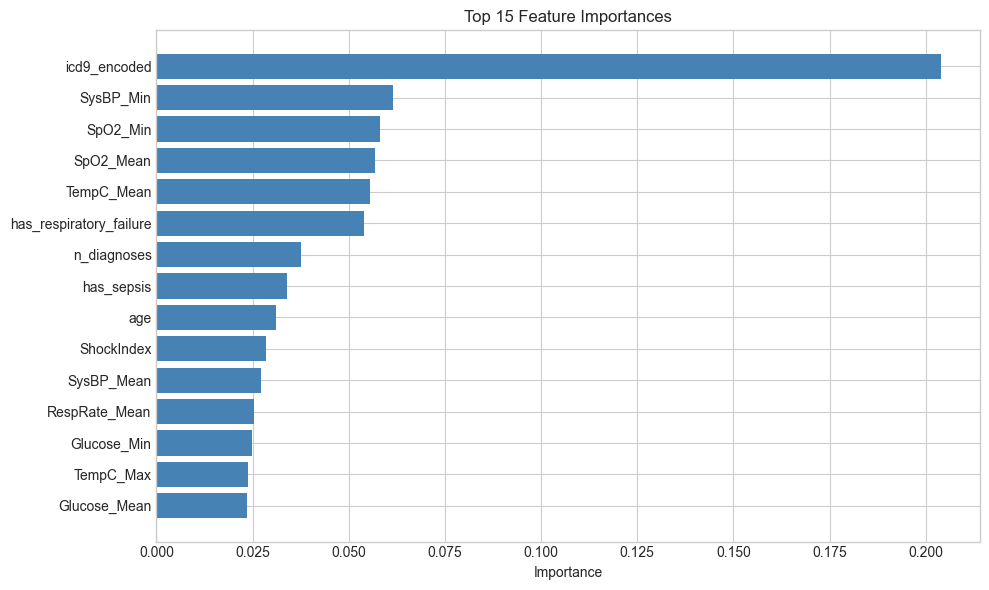

In [33]:
# =============================================================================
# 7.2 FEATURE IMPORTANCE
# =============================================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Top 15)")
print("="*60)

# Get feature importances
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n")
for i, row in importance_df.head(15).iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"{row['feature']:<25} {row['importance']:.4f} {bar}")

# Plot
plt.figure(figsize=(10, 6))
top15 = importance_df.head(15)
plt.barh(range(len(top15)), top15['importance'], color='steelblue')
plt.yticks(range(len(top15)), top15['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


ROC CURVE


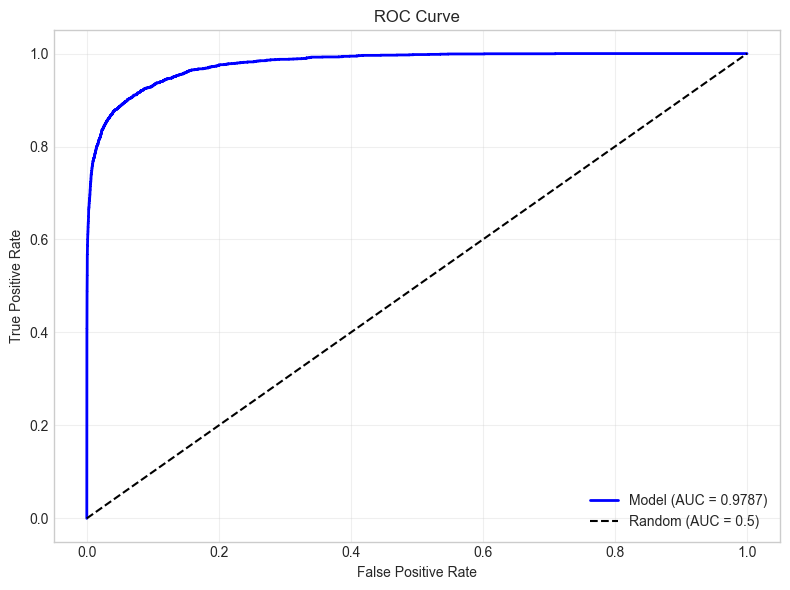


Training ROC-AUC: 0.9787
CV ROC-AUC: 0.9024


In [34]:
# =============================================================================
# 7.3 ROC CURVE
# =============================================================================

print("\n" + "="*60)
print("ROC CURVE")
print("="*60)

# Training predictions
train_proba = final_model.predict_proba(X)[:, 1]
train_auc = roc_auc_score(y, train_proba)

# ROC curve
fpr, tpr, thresholds = roc_curve(y, train_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Model (AUC = {train_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTraining ROC-AUC: {train_auc:.4f}")
print(f"CV ROC-AUC: {verify_scores.mean():.4f}")

<a id='8-predictions'></a>
## 8. Predictions & Submission

GENERATING TEST PREDICTIONS

Prediction Statistics:
  Count: 5221
  Min:   0.0006
  Max:   0.9982
  Mean:  0.1105


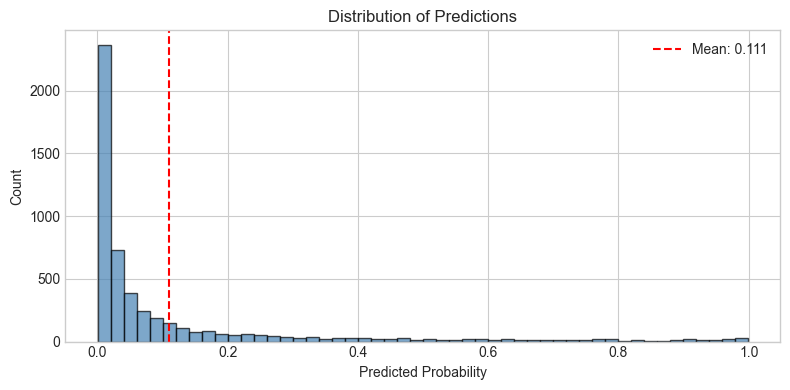

In [35]:
# =============================================================================
# 8.1 GENERATE PREDICTIONS
# =============================================================================

print("="*60)
print("GENERATING TEST PREDICTIONS")
print("="*60)

# Predict probabilities for test set
test_proba = final_model.predict_proba(X_test)[:, 1]

print(f"\nPrediction Statistics:")
print(f"  Count: {len(test_proba)}")
print(f"  Min:   {test_proba.min():.4f}")
print(f"  Max:   {test_proba.max():.4f}")
print(f"  Mean:  {test_proba.mean():.4f}")

# Distribution
plt.figure(figsize=(8, 4))
plt.hist(test_proba, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(test_proba.mean(), color='red', linestyle='--', label=f'Mean: {test_proba.mean():.3f}')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Distribution of Predictions')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 8.2 CREATE SUBMISSION FILE
# =============================================================================

print("\n" + "="*60)
print("CREATING SUBMISSION FILE")
print("="*60)

# Create submission dataframe
submission = pd.DataFrame({
    'icustay_id': test_ids,
    'prediction': test_proba
})

# Validate
assert len(submission) == len(X_test), "Length mismatch!"
assert submission['prediction'].notna().all(), "NaN in predictions!"
assert (submission['prediction'] >= 0).all() and (submission['prediction'] <= 1).all(), "Invalid probabilities!"

print(f"\nValidation passed:")
print(f"  - {len(submission)} predictions")
print(f"  - No missing values")
print(f"  - All probabilities in [0, 1]")

# Save
filename = 'moons_corneel_CML_2025.csv'
submission.to_csv(filename, index=False)

print(f"\nSaved: {filename}")
print(f"\nPreview:")
print(submission.head(10).to_string(index=False))


CREATING SUBMISSION FILE

Validation passed:
  - 5221 predictions
  - No missing values
  - All probabilities in [0, 1]

Saved: vandenbosch_corneel_CML_2025.csv

Preview:
 icustay_id  prediction
     252542    0.011669
     264253    0.162688
     253139    0.003706
     222630    0.003114
     274518    0.002689
     232807    0.008461
     201272    0.004795
     292343    0.060926
     227008    0.114266
     282599    0.058896


<a id='9-conclusion'></a>
## 9. Conclusion

In [37]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print(f"\n1. DATA")
print(f"   Training samples: {len(X):,}")
print(f"   Test samples: {len(X_test):,}")
print(f"   Features: {X.shape[1]}")
print(f"   Class imbalance: {y.mean():.1%} mortality")

print(f"\n2. PREPROCESSING")
print(f"   - Hospital history features (previous ICU visits)")
print(f"   - Diagnosis features (ICD9 codes, high-risk conditions)")
print(f"   - Medical severity indicators (shock index, hypoxemia)")
print(f"   - Missing value imputation (median/mode)")
print(f"   - Target encoding for high-cardinality features")
print(f"   - StandardScaler for continuous features")

print(f"\n3. MODEL SELECTION (5-Fold Stratified CV)")
print(f"   Logistic Regression: {lr_scores.mean():.4f}")
print(f"   Random Forest:       {rf_scores.mean():.4f}")
print(f"   Gradient Boosting:   {gb_scores.mean():.4f}")

print(f"\n4. HYPERPARAMETER TUNING (GridSearchCV)")
print(f"   Best parameters:")
for param, value in grid_search.best_params_.items():
    print(f"     {param}: {value}")

print(f"\n5. FINAL PERFORMANCE")
print(f"   CV ROC-AUC: {verify_scores.mean():.4f} (+/- {verify_scores.std():.4f})")

print(f"\n6. OUTPUT")
print(f"   File: {filename}")

print("\n" + "="*60)
print("END OF NOTEBOOK")
print("="*60)

PROJECT SUMMARY

1. DATA
   Training samples: 20,885
   Test samples: 5,221
   Features: 1962
   Class imbalance: 11.2% mortality

2. PREPROCESSING
   - Hospital history features (previous ICU visits)
   - Diagnosis features (ICD9 codes, high-risk conditions)
   - Medical severity indicators (shock index, hypoxemia)
   - Missing value imputation (median/mode)
   - Target encoding for high-cardinality features
   - StandardScaler for continuous features

3. MODEL SELECTION (5-Fold Stratified CV)
   Logistic Regression: 0.8820
   Random Forest:       0.8869
   Gradient Boosting:   0.8904

4. HYPERPARAMETER TUNING (GridSearchCV)
   Best parameters:
     learning_rate: 0.1
     max_depth: 5
     min_samples_leaf: 20
     n_estimators: 300

5. FINAL PERFORMANCE
   CV ROC-AUC: 0.9024 (+/- 0.0061)

6. OUTPUT
   File: vandenbosch_corneel_CML_2025.csv

END OF NOTEBOOK


---

## Key Design Decisions

| Decision | Rationale |
|----------|----------|
| **Stratified K-Fold CV** | Preserves 11% mortality rate in each fold |
| **class_weight='balanced'** | Handles class imbalance in Logistic Regression |
| **Gradient Boosting** | Best CV performance among tested models |
| **GridSearchCV** | Systematic search with CV for each combination |
| **Target encoding** | Handles 500+ ICD9 categories without feature explosion |
| **Shock Index** | Clinically validated predictor of ICU mortality |
| **predict_proba** | Returns probabilities as required by assignment |

---